# LLM Response Time per Phase

Plots mean response time over benchmark steps for each LLM model, with phase regions (low / medium / high) shaded in the background. Lines are mean across iterations and across agents (api1, api2).

In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# --- Config ---
RESULTS_DIR = '../results/benchmark/small'

# Which LLM models to plot, with display name and color.
MODELS = [
    ('llm_vpa_ollama_llama3_8b',      'llama3:8b',     '#1f77b4'),
    ('llm_vpa_ollama_qwen2_5_7b',     'qwen2.5:7b',    '#ff7f0e'),
    # ('llm_ollama_gemma_7b',       'gemma:7b',      '#2ca02c'),
    ('llm_vpa_ollama_mistral_latest', 'mistral:7b',       '#d62728'),
]

# Phase order on x-axis (matches benchmark_config.yaml load_patterns)
PHASES = ['low', 'medium', 'high']
PHASE_COLORS = {'low': '#e8f4f8', 'medium': '#fff4e6', 'high': '#fde8e8'}

In [7]:
def load_model(tag):
    """Load all iterations for a model and return a DataFrame."""
    files = sorted(glob.glob(os.path.join(RESULTS_DIR, f'{tag}_iter*_metrics.csv')))
    if not files:
        return None
    dfs = [pd.read_csv(f) for f in files]
    return pd.concat(dfs, ignore_index=True)

# Quick check that data exists
for tag, name, _ in MODELS:
    df = load_model(tag)
    if df is None:
        print(f'  {name:15s}: NO DATA')
    else:
        print(f'  {name:15s}: {len(df)} rows across {df.groupby(["phase"]).ngroups} phases')

  llama3:8b      : 7200 rows across 3 phases
  qwen2.5:7b     : 7200 rows across 3 phases
  mistral:7b     : 7200 rows across 3 phases


In [8]:
def per_step_mean_rt(df):
    """Returns a DataFrame indexed by global step number with the mean response_time.
    Averages across both agents and all iterations."""
    # Within each iteration the runner stamps a monotonic 'step' column (0..179 for 3 phases x 60 steps).
    # We average rt across (agent_id, iteration) for the same step number.
    g = df.groupby('step', as_index=True)
    out = pd.DataFrame({
        'mean_rt': g['response_time'].mean(),
        'phase':   g['phase'].first(),
    })
    return out

# Build the per-step series for each model
series = {}
for tag, name, color in MODELS:
    df = load_model(tag)
    if df is None:
        continue
    series[name] = (per_step_mean_rt(df), color)

list(series.keys())

['llama3:8b', 'qwen2.5:7b', 'mistral:7b']

In [9]:
# Determine phase boundaries from the first available model (they should match across models)
first_model = next(iter(series.values()))[0]
phase_ranges = {}
for phase in PHASES:
    idx = first_model.index[first_model['phase'] == phase]
    if len(idx):
        phase_ranges[phase] = (idx.min(), idx.max())
phase_ranges

{'low': (np.int64(0), np.int64(59)),
 'medium': (np.int64(60), np.int64(119)),
 'high': (np.int64(120), np.int64(179))}

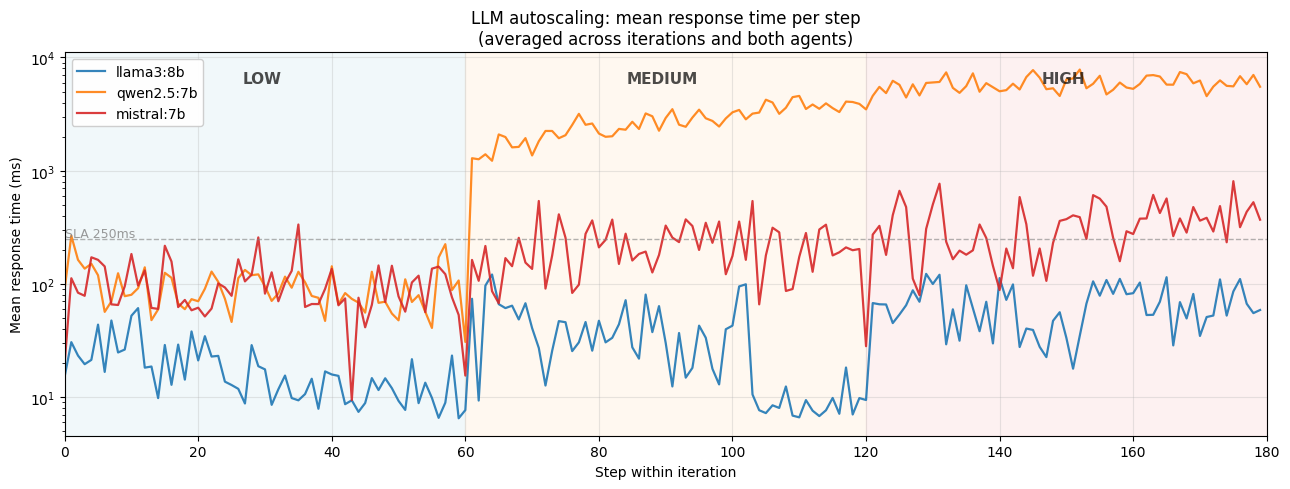

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))

# Shaded phase regions in the background
for phase, (lo, hi) in phase_ranges.items():
    ax.axvspan(lo, hi + 1, color=PHASE_COLORS[phase], alpha=0.6, zorder=0)
    mid = (lo + hi) / 2
    ax.text(mid, 0.95, phase.upper(), transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=11, fontweight='bold', alpha=0.7)

# One line per model
for name, (s, color) in series.items():
    ax.plot(s.index, s['mean_rt'] * 1000, label=name, color=color, linewidth=1.6, alpha=0.9)

# 250ms SLA threshold
ax.axhline(250, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(0, 260, 'SLA 250ms', color='gray', fontsize=9, alpha=0.8)

ax.set_xlabel('Step within iteration')
ax.set_ylabel('Mean response time (ms)')
ax.set_title('LLM autoscaling: mean response time per step\n(averaged across iterations and both agents)')
ax.set_yscale('log')
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(p[1] for p in phase_ranges.values()) + 1)
plt.tight_layout()
plt.show()

## Linear-scale version

The log-scale plot above lets you see all four models at once even though they span 3 orders of magnitude. Below is the same data on a linear y-axis — llama3 will look like a flat line near zero because the others dwarf it.

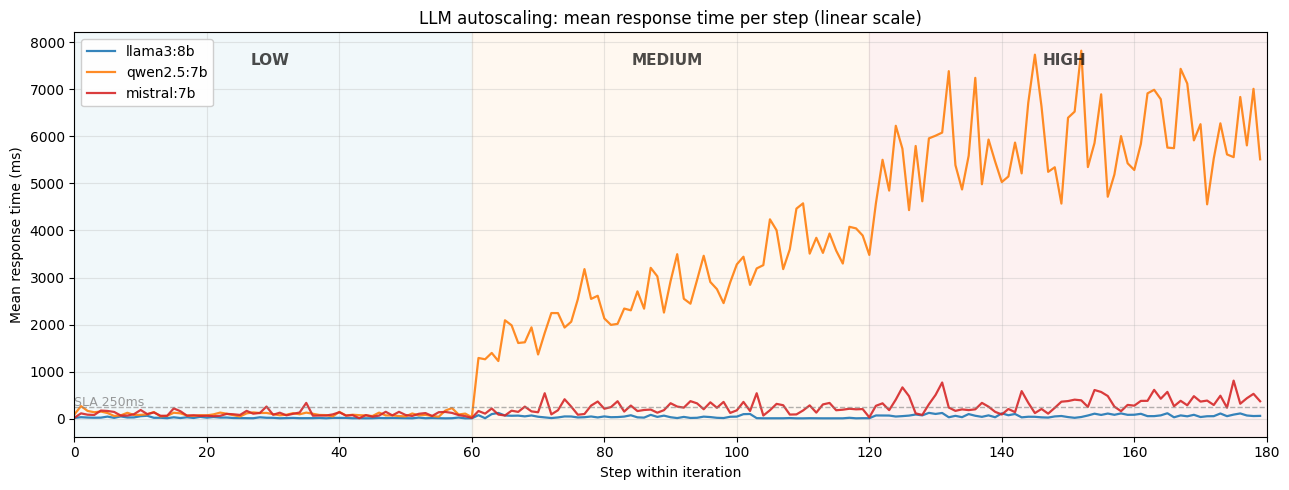

In [11]:
fig, ax = plt.subplots(figsize=(13, 5))

for phase, (lo, hi) in phase_ranges.items():
    ax.axvspan(lo, hi + 1, color=PHASE_COLORS[phase], alpha=0.6, zorder=0)
    mid = (lo + hi) / 2
    ax.text(mid, 0.95, phase.upper(), transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=11, fontweight='bold', alpha=0.7)

for name, (s, color) in series.items():
    ax.plot(s.index, s['mean_rt'] * 1000, label=name, color=color, linewidth=1.6, alpha=0.9)

ax.axhline(250, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(0, 260, 'SLA 250ms', color='gray', fontsize=9, alpha=0.8)

ax.set_xlabel('Step within iteration')
ax.set_ylabel('Mean response time (ms)')
ax.set_title('LLM autoscaling: mean response time per step (linear scale)')
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(p[1] for p in phase_ranges.values()) + 1)
plt.tight_layout()
plt.show()

## Optional: only llama3 (the model that stays under SLA)

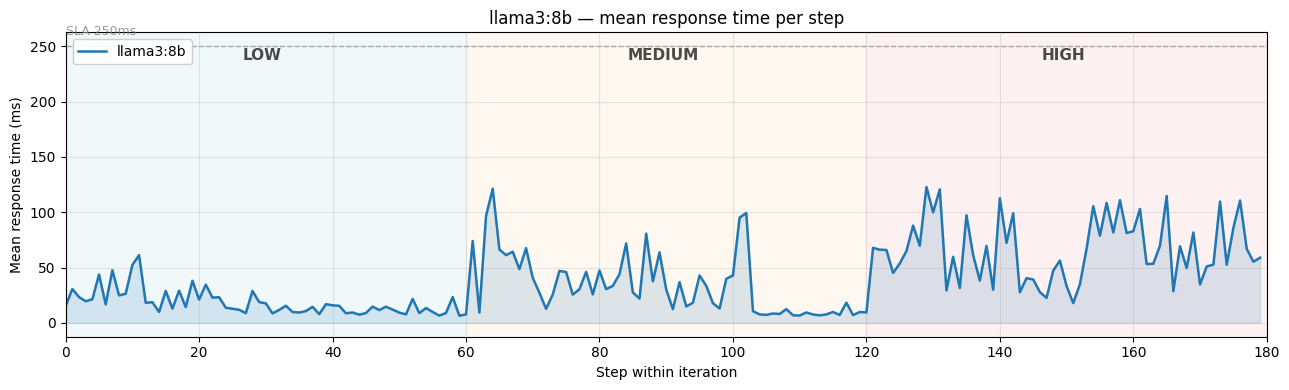

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))

for phase, (lo, hi) in phase_ranges.items():
    ax.axvspan(lo, hi + 1, color=PHASE_COLORS[phase], alpha=0.6, zorder=0)
    mid = (lo + hi) / 2
    ax.text(mid, 0.95, phase.upper(), transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=11, fontweight='bold', alpha=0.7)

name = 'llama3:8b'
if name in series:
    s, color = series[name]
    ax.plot(s.index, s['mean_rt'] * 1000, label=name, color=color, linewidth=1.8)
    ax.fill_between(s.index, 0, s['mean_rt'] * 1000, color=color, alpha=0.15)

ax.axhline(250, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(0, 260, 'SLA 250ms', color='gray', fontsize=9, alpha=0.8)

ax.set_xlabel('Step within iteration')
ax.set_ylabel('Mean response time (ms)')
ax.set_title('llama3:8b — mean response time per step')
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(p[1] for p in phase_ranges.values()) + 1)
plt.tight_layout()
plt.show()

---

# Extended analyses

The cells below use the same `MODELS`, `series`, `phase_ranges`, and `PHASE_COLORS` defined earlier.
First, a couple of shared helpers used across the plots.

In [13]:
def parse_action(s):
    """Parse the 'action' column. RL agents store scalars; joint agents store arrays."""
    s = str(s).strip()
    if s.startswith('['):
        parts = s.strip('[]').split()
        v = float(parts[0])
        h = float(parts[1]) if len(parts) > 1 else 0.0
        return v, h
    try:
        return float(s), 0.0
    except Exception:
        return 0.0, 0.0


def categorize_action(v, h, eps=1e-6):
    """Classify each action as VPA-up/-down, HPA-up/-down, or no_action."""
    av, ah = abs(v), abs(h)
    if av > eps and ah <= eps:
        return 'VPA-up' if v > 0 else 'VPA-down'
    if ah > eps and av <= eps:
        return 'HPA-up' if h > 0 else 'HPA-down'
    if av > eps and ah > eps:
        return 'mixed'
    return 'no_action'


def shade_phases(ax):
    """Apply the shared phase shading + labels onto an Axes."""
    for phase, (lo, hi) in phase_ranges.items():
        ax.axvspan(lo, hi + 1, color=PHASE_COLORS[phase], alpha=0.5, zorder=0)
        mid = (lo + hi) / 2
        ax.text(mid, 0.97, phase.upper(), transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=10, fontweight='bold', alpha=0.7)


def per_step_mean(df, col):
    g = df.groupby('step', as_index=True)
    return pd.DataFrame({col: g[col].mean(), 'phase': g['phase'].first()})


# Pre-load each model's raw DataFrame once for reuse
raw = {}
for tag, name, color in MODELS:
    d = load_model(tag)
    if d is not None:
        raw[name] = (d, color)
list(raw.keys())

['llama3:8b', 'qwen2.5:7b', 'mistral:7b']

## 1. CPU limit and usage over time

For each model, the **dashed line** is the agent-controlled `cpu_limit` (in millicores) and the **solid line** is actual `cpu_usage`. When `usage` is near `limit`, the pod is saturated. When `limit` is much larger than `usage`, the agent is over-provisioning. This is the smoking gun for "did the LLM actually scale CPU?".

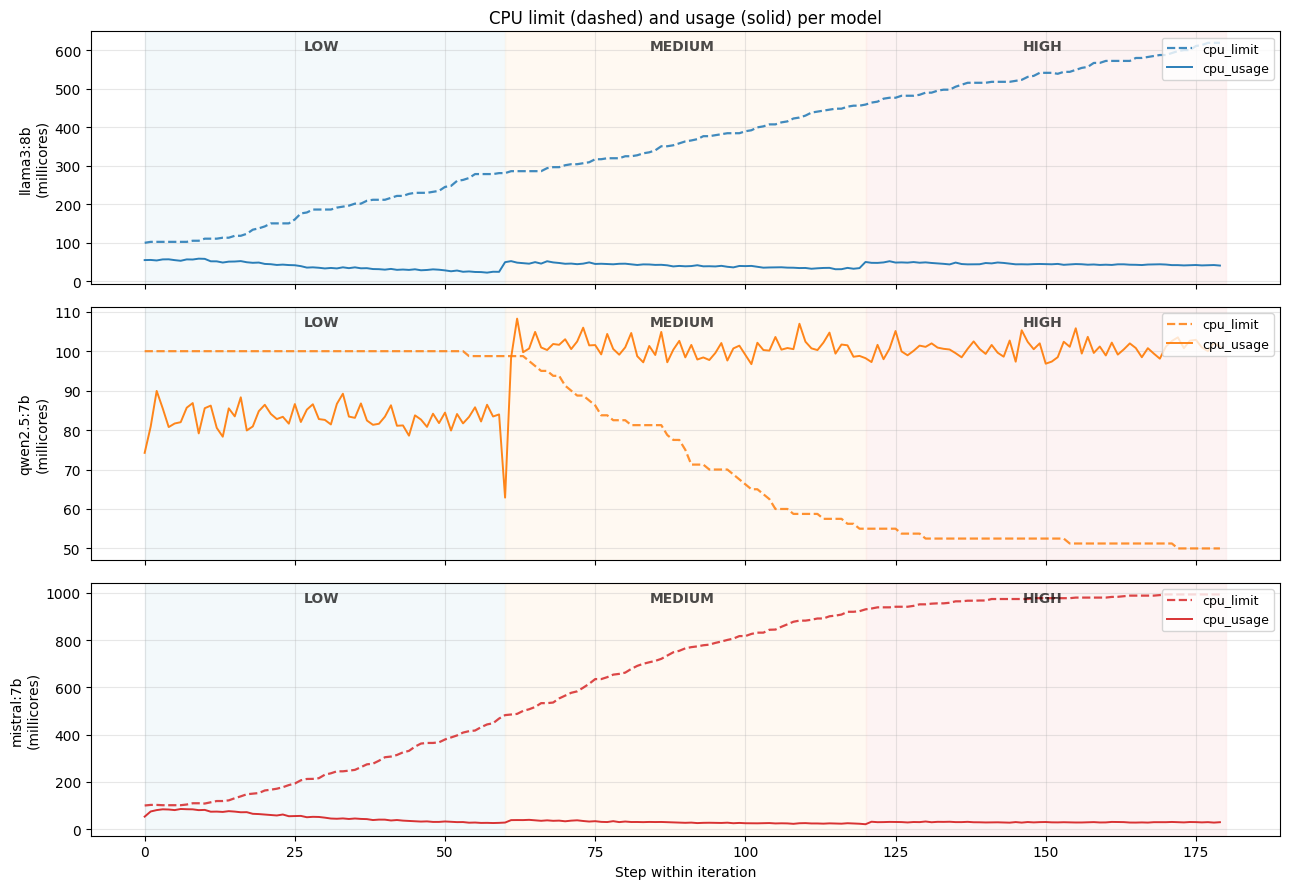

In [14]:
n = len(raw)
fig, axes = plt.subplots(n, 1, figsize=(13, 3 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, (name, (df, color)) in zip(axes, raw.items()):
    cl = per_step_mean(df, 'cpu_limit')
    cu = per_step_mean(df, 'cpu_usage')
    shade_phases(ax)
    ax.plot(cl.index, cl['cpu_limit'], '--', label='cpu_limit', color=color, linewidth=1.6, alpha=0.85)
    ax.plot(cu.index, cu['cpu_usage'], '-', label='cpu_usage', color=color, linewidth=1.4, alpha=0.95)
    ax.set_ylabel(f'{name}\n(millicores)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Step within iteration')
axes[0].set_title('CPU limit (dashed) and usage (solid) per model')
plt.tight_layout()
plt.show()

## 2. Replica count over time

One step plot per model. Mean number of replicas across both deployments (api1, api2). Integer-ish values; small fractional offsets come from iteration averaging.

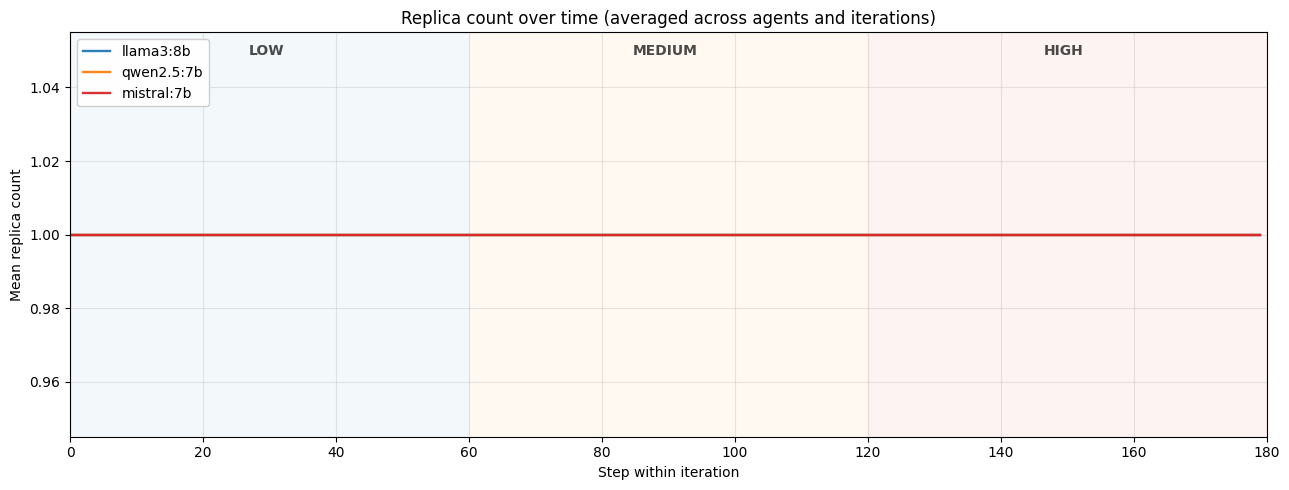

In [15]:
fig, ax = plt.subplots(figsize=(13, 5))
shade_phases(ax)

for name, (df, color) in raw.items():
    rep = per_step_mean(df, 'replica_count')
    ax.plot(rep.index, rep['replica_count'], label=name, color=color, linewidth=1.7, alpha=0.95)

ax.set_xlabel('Step within iteration')
ax.set_ylabel('Mean replica count')
ax.set_title('Replica count over time (averaged across agents and iterations)')
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(p[1] for p in phase_ranges.values()) + 1)
plt.tight_layout()
plt.show()

## 3. Action timeline per model

Each row is a model; each column is a step. The color shows the **action taken** at that step (averaged across agents → for each step, the most common category wins). Quick visual fingerprint of strategy.

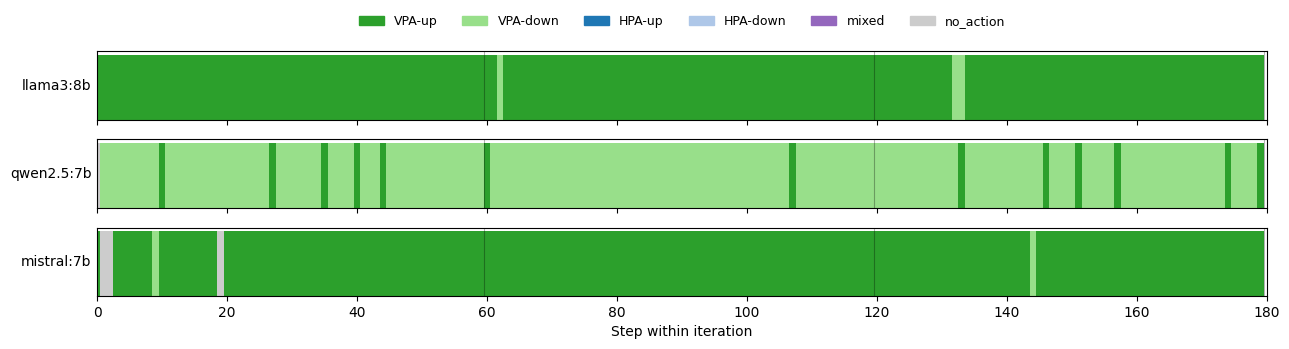

In [16]:
from collections import Counter

ACTION_COLORS = {
    'VPA-up':    '#2ca02c',
    'VPA-down':  '#98df8a',
    'HPA-up':    '#1f77b4',
    'HPA-down':  '#aec7e8',
    'mixed':     '#9467bd',
    'no_action': '#cccccc',
}
ACTION_ORDER = ['VPA-up', 'VPA-down', 'HPA-up', 'HPA-down', 'mixed', 'no_action']

n = len(raw)
fig, axes = plt.subplots(n, 1, figsize=(13, 0.9 * n + 1), sharex=True)
if n == 1:
    axes = [axes]

for ax, (name, (df, color)) in zip(axes, raw.items()):
    # Per-row action category
    pairs = df['action'].apply(parse_action)
    df_local = df.assign(cat=[categorize_action(v, h) for v, h in pairs])
    # Most-frequent category per step
    per_step_cat = df_local.groupby('step')['cat'].agg(lambda s: Counter(s).most_common(1)[0][0])
    steps = per_step_cat.index.values
    colors_per_step = [ACTION_COLORS[c] for c in per_step_cat.values]
    ax.bar(steps, [1]*len(steps), width=1.0, color=colors_per_step, edgecolor='none')
    ax.set_yticks([])
    ax.set_ylabel(name, rotation=0, ha='right', va='center')
    ax.set_xlim(0, max(p[1] for p in phase_ranges.values()) + 1)
    for phase, (lo, hi) in phase_ranges.items():
        ax.axvline(hi + 0.5, color='black', linewidth=0.8, alpha=0.3)

# Shared legend
handles = [plt.Rectangle((0,0), 1, 1, color=ACTION_COLORS[c]) for c in ACTION_ORDER]
axes[0].legend(handles, ACTION_ORDER, loc='upper center', bbox_to_anchor=(0.5, 1.7),
               ncol=len(ACTION_ORDER), frameon=False, fontsize=9)
axes[-1].set_xlabel('Step within iteration')
plt.tight_layout()
plt.show()

## 4. CPU utilization over time (target band shaded)

The horizontal stripe between **30% and 60%** is the agent's target band. A good policy keeps the line inside it; a bad policy lives at 100% (saturated).

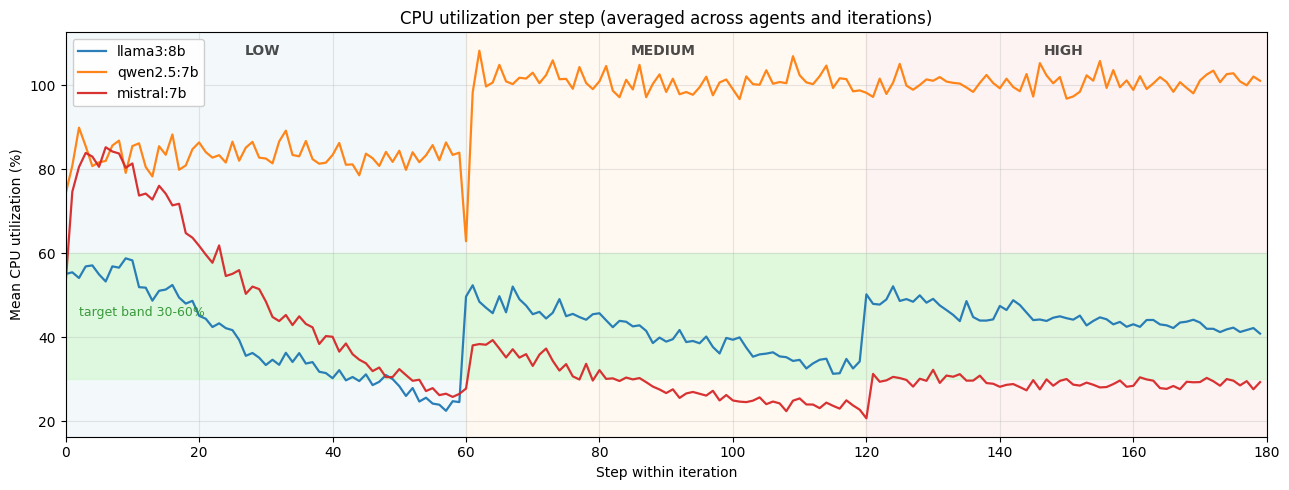

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
shade_phases(ax)
ax.axhspan(30, 60, color='#d4f8d4', alpha=0.7, zorder=0)
ax.text(2, 45, 'target band 30-60%', fontsize=9, color='#2a8f2a', alpha=0.9)

for name, (df, color) in raw.items():
    cpu = per_step_mean(df, 'cpu_percentage')
    ax.plot(cpu.index, cpu['cpu_percentage'], label=name, color=color, linewidth=1.6, alpha=0.95)

ax.set_xlabel('Step within iteration')
ax.set_ylabel('Mean CPU utilization (%)')
ax.set_title('CPU utilization per step (averaged across agents and iterations)')
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(p[1] for p in phase_ranges.values()) + 1)
plt.tight_layout()
plt.show()

## 5. Cumulative reward over time

Running sum of mean reward per step. Higher = better policy. Slope changes when a model enters a new phase or its strategy fails.

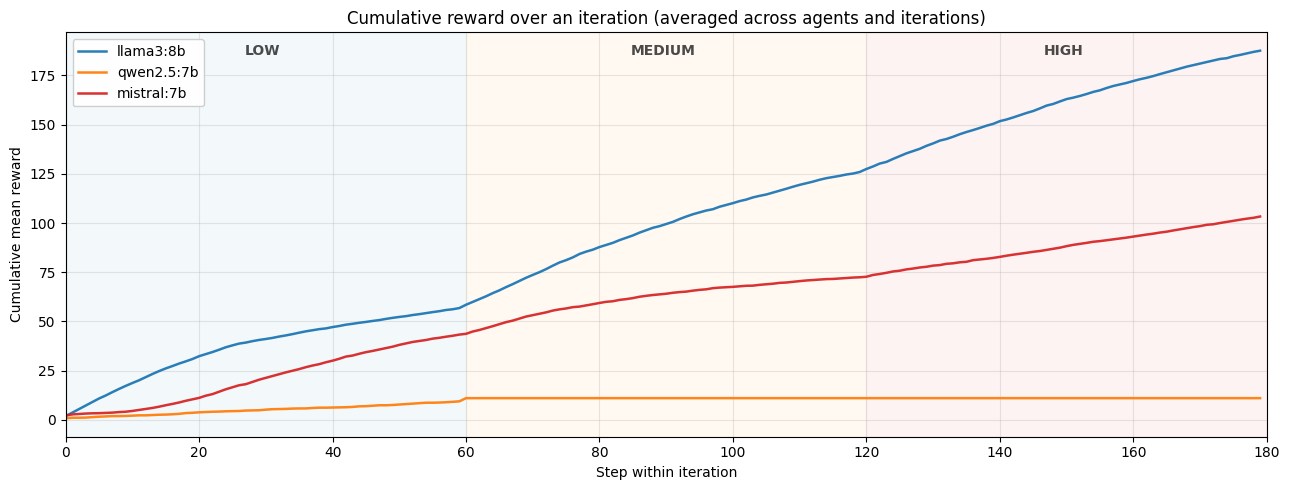

In [18]:
fig, ax = plt.subplots(figsize=(13, 5))
shade_phases(ax)

for name, (df, color) in raw.items():
    rew = per_step_mean(df, 'reward')
    ax.plot(rew.index, rew['reward'].cumsum(), label=name, color=color, linewidth=1.8, alpha=0.95)

ax.set_xlabel('Step within iteration')
ax.set_ylabel('Cumulative mean reward')
ax.set_title('Cumulative reward over an iteration (averaged across agents and iterations)')
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(p[1] for p in phase_ranges.values()) + 1)
plt.tight_layout()
plt.show()

## 6. Response time distribution per phase

Boxplot per (model, phase) showing the full RT distribution, not just the mean. The whiskers + outliers reveal tail behavior that line plots hide. Log y-axis because the spread is large.

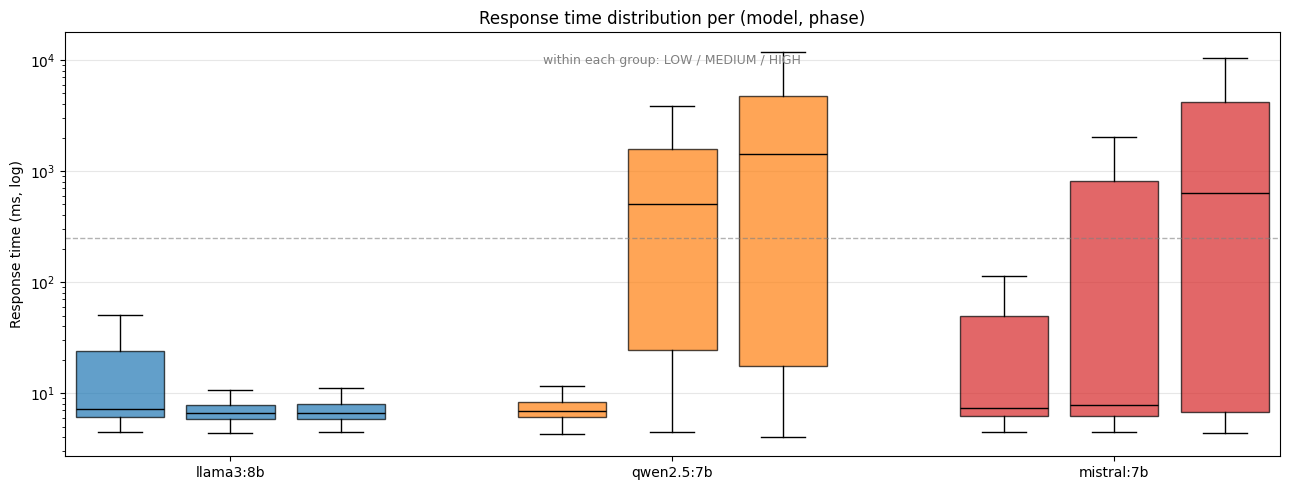

In [26]:
rows = []
for name, (df, color) in raw.items():
    for phase in PHASES:
        pdf = df[df['phase'] == phase]
        for rt in pdf['response_time']:
            rows.append({'model': name, 'phase': phase, 'rt_ms': rt * 1000})
plot_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(13, 5))
models_in_order = list(raw.keys())
positions = []
data = []
colors = []
for j, name in enumerate(models_in_order):
    for i, phase in enumerate(PHASES):
        positions.append(j * (len(PHASES) + 1) + i)
        data.append(plot_df[(plot_df['model']==name) & (plot_df['phase']==phase)]['rt_ms'])
        colors.append(raw[name][1])

bp = ax.boxplot(data, positions=positions, widths=0.8, patch_artist=True,
                showfliers=False, medianprops=dict(color='black'))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)

ax.set_yscale('log')
ax.axhline(250, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_ylabel('Response time (ms, log)')
ax.set_xticks([j * (len(PHASES) + 1) + 1 for j in range(len(models_in_order))])
ax.set_xticklabels(models_in_order)
ax.set_title('Response time distribution per (model, phase)')
# Phase legend
phase_labels = ' / '.join(p.upper() for p in PHASES)
ax.text(0.5, 0.95, f'within each group: {phase_labels}', transform=ax.transAxes,
        ha='center', va='top', fontsize=9, color='gray')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. Decision latency over time

Mean per-decision latency at each step. Useful to see whether prompt-context bloat or load makes the LLM slow down across an iteration.

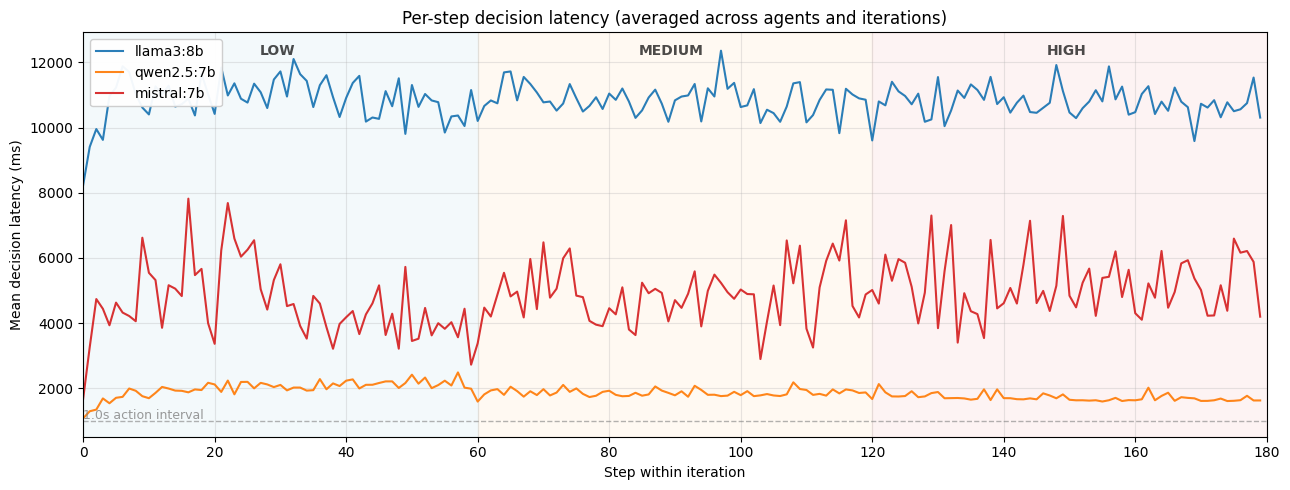

In [27]:
fig, ax = plt.subplots(figsize=(13, 5))
shade_phases(ax)

for name, (df, color) in raw.items():
    lat = per_step_mean(df, 'decision_latency_ms')
    ax.plot(lat.index, lat['decision_latency_ms'], label=name, color=color, linewidth=1.5, alpha=0.95)

ax.axhline(1000, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(0, 1050, '1.0s action interval', color='gray', fontsize=9, alpha=0.8)
ax.set_xlabel('Step within iteration')
ax.set_ylabel('Mean decision latency (ms)')
ax.set_title('Per-step decision latency (averaged across agents and iterations)')
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(p[1] for p in phase_ranges.values()) + 1)
plt.tight_layout()
plt.show()

## 8. Per-iteration convergence

For each model: faded lines = individual iterations, bold line = mean. Tight spread = consistent policy. Wide spread = stochastic/unstable behavior.

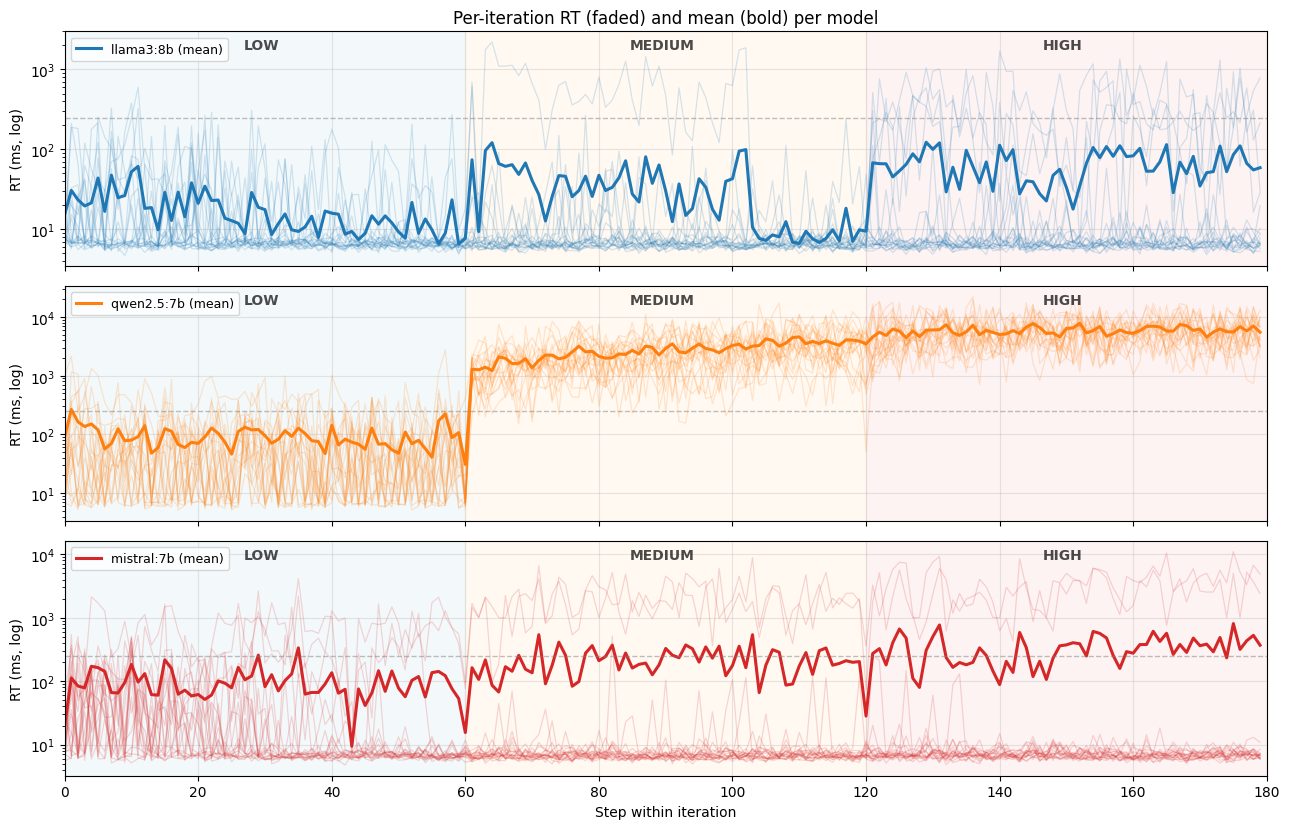

In [19]:
n = len(raw)
fig, axes = plt.subplots(n, 1, figsize=(13, 2.8 * n), sharex=True, sharey=False)
if n == 1:
    axes = [axes]

for ax, (name, (df, color)) in zip(axes, raw.items()):
    shade_phases(ax)
    iter_files = sorted(glob.glob(os.path.join(RESULTS_DIR, f"{[tag for tag, n2, _ in MODELS if n2 == name][0]}_iter*_metrics.csv")))
    for f in iter_files:
        d = pd.read_csv(f)
        s = d.groupby('step')['response_time'].mean() * 1000
        ax.plot(s.index, s.values, color=color, alpha=0.18, linewidth=0.9)
    # Mean across iterations
    all_d = pd.concat([pd.read_csv(f) for f in iter_files])
    mean_s = all_d.groupby('step')['response_time'].mean() * 1000
    ax.plot(mean_s.index, mean_s.values, color=color, linewidth=2.2, label=f'{name} (mean)')
    ax.axhline(250, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_yscale('log')
    ax.set_ylabel('RT (ms, log)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, max(p[1] for p in phase_ranges.values()) + 1)

axes[-1].set_xlabel('Step within iteration')
axes[0].set_title('Per-iteration RT (faded) and mean (bold) per model')
plt.tight_layout()
plt.show()

## 9. Action mix per phase

For each (model, phase), the stacked bar shows what fraction of decisions went to each action category. Quick visual comparison of strategy across the load curve.

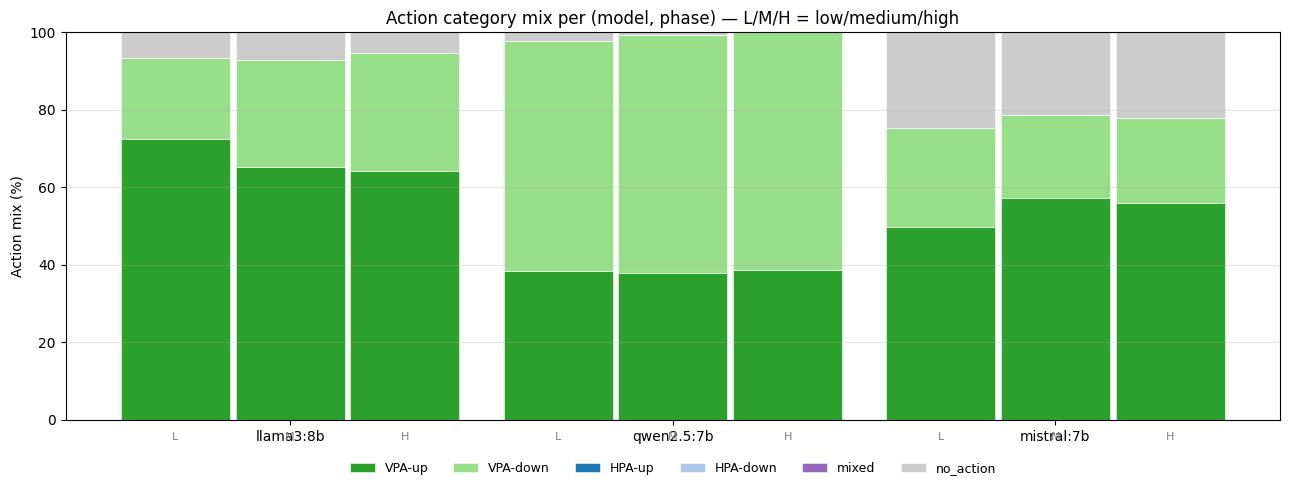

In [20]:
rows = []
for name, (df, color) in raw.items():
    pairs = df['action'].apply(parse_action)
    df2 = df.assign(cat=[categorize_action(v, h) for v, h in pairs])
    for phase in PHASES:
        sub = df2[df2['phase'] == phase]
        counts = sub['cat'].value_counts(normalize=True) * 100
        for cat in ACTION_ORDER:
            rows.append({'model': name, 'phase': phase, 'cat': cat, 'pct': counts.get(cat, 0)})
mix = pd.DataFrame(rows)

models_in_order = list(raw.keys())
fig, ax = plt.subplots(figsize=(13, 5))
group_w = 0.9
bar_w = group_w / len(PHASES)

for i, phase in enumerate(PHASES):
    bottom = np.zeros(len(models_in_order))
    for cat in ACTION_ORDER:
        vals = [mix[(mix['model']==m) & (mix['phase']==phase) & (mix['cat']==cat)]['pct'].iloc[0]
                for m in models_in_order]
        x = np.arange(len(models_in_order)) + (i - 1) * bar_w
        ax.bar(x, vals, bottom=bottom, width=bar_w * 0.95, color=ACTION_COLORS[cat],
               edgecolor='white', linewidth=0.4,
               label=cat if i == 0 else None)
        bottom += np.array(vals)
    # phase tick label under the group
    for j, m in enumerate(models_in_order):
        ax.text(j + (i - 1) * bar_w, -3, phase[0].upper(), ha='center', va='top', fontsize=8, color='gray')

ax.set_xticks(np.arange(len(models_in_order)))
ax.set_xticklabels(models_in_order)
ax.set_ylabel('Action mix (%)')
ax.set_title('Action category mix per (model, phase) — L/M/H = low/medium/high')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=len(ACTION_ORDER), frameon=False, fontsize=9)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 10. Reward vs decision latency

One marker per iteration (faded) + one big marker for the per-model mean. Tests the **"quality vs speed"** hypothesis. Top-right = slow but high reward (e.g. llama3). Bottom-left = fast but low reward (e.g. qwen).

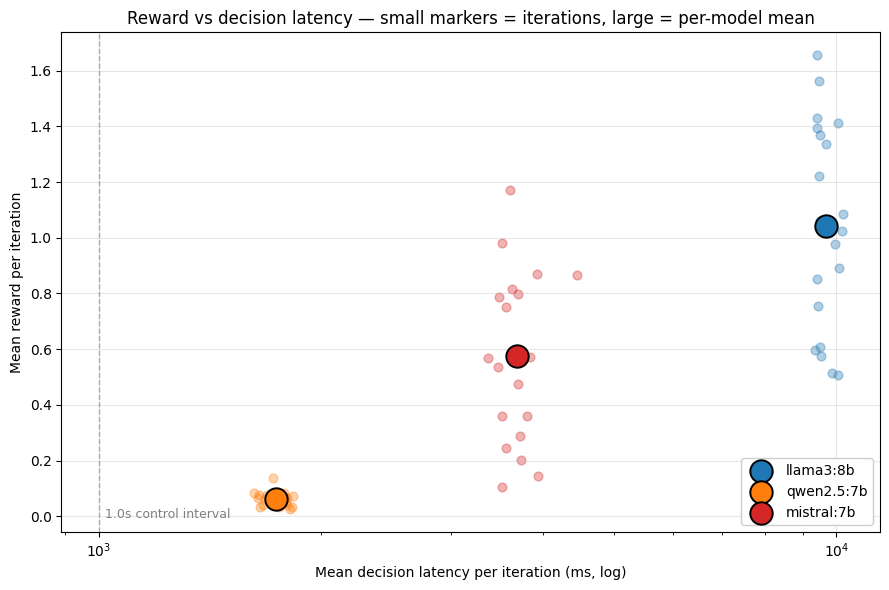

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, (df, color) in raw.items():
    iter_files = sorted(glob.glob(os.path.join(RESULTS_DIR, f"{[tag for tag, n2, _ in MODELS if n2 == name][0]}_iter*_metrics.csv")))
    iter_pts = []
    for f in iter_files:
        d = pd.read_csv(f)
        iter_pts.append((d['decision_latency_ms'].mean(), d['reward'].mean()))
    if not iter_pts:
        continue
    xs, ys = zip(*iter_pts)
    ax.scatter(xs, ys, color=color, alpha=0.35, s=40)
    ax.scatter([np.mean(xs)], [np.mean(ys)], color=color, s=260, edgecolor='black',
               linewidth=1.4, zorder=5, label=name)

ax.axvline(1000, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(1020, ax.get_ylim()[0] + 0.05, '1.0s control interval', color='gray', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Mean decision latency per iteration (ms, log)')
ax.set_ylabel('Mean reward per iteration')
ax.set_title('Reward vs decision latency — small markers = iterations, large = per-model mean')
ax.legend(loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()